# XGBoost Portfolio Weights — Simple Example

**Workflow:**
1. Load prices for your custom ticker universe
2. Build features + forward-return target
3. Train/val/test split (using toolkit helpers)
4. Fit XGBoost on `expected_return`
5. Emit the standard prediction table
6. Convert predictions → portfolio weights via toolkit builders
7. Backtest and inspect metrics

No MLflow is required for this minimal example, but a log block is included at the bottom if you want it.

## 0. Install / Imports

!git clone https://github.com/adamthorne27/Portfolio-Optimization-Lib.git
%cd Portfolio-Optimization-Lib
!pip install -e ".[dev]"
!pip install xgboost

In [1]:
!git clone https://github.com/adamthorne27/Portfolio-Optimization-Lib.git
%cd Portfolio-Optimization-Lib
!pip install -e ".[dev]"
!pip install xgboost

fatal: destination path 'Portfolio-Optimization-Lib' already exists and is not an empty directory.
/Users/eamonnavin/Downloads/Portfolio-Optimization-Lib/notebooks/templates/Portfolio-Optimization-Lib
zsh:1: command not found: pip
zsh:1: command not found: pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import xgboost as xgb
import mlflow
from sklearn.metrics import mean_squared_error

from portfolio_toolkit import (
    load_prices,
    build_features,
    make_forward_return_target,
    slice_split,
    validate_prediction_frame,
    weights_from_predictions_top_k_equal,
    weights_from_predictions_rank_long_only,
    backtest_weights,
    build_metrics,
    write_backtest_artifacts,
    init_mlflow,
    start_run,
    log_predictions,
    log_portfolio,
    log_backtest,
)

print("Imports OK")

Imports OK


## 1. Configuration

Edit `TICKERS` to whatever universe you want. `DATASET_NAME` is just a label used for the backtest and weight validation — it does **not** need to match a preset in `configs/datasets.toml` when you supply your own ticker list directly to `load_prices`.

> **If you want to use a shared preset instead**, replace the `TICKERS` block with:
> ```python
> prices = load_prices("shared_set_2")  # pulls tickers + splits from TOML
> ```
> and set `DATASET_NAME = "shared_set_2"` so the backtest inherits the correct split dates.

In [3]:
# repo_root points to the Portfolio-Optimization-Lib folder on your machine.
# Adjust this path if your repo lives somewhere other than ~/Downloads/.
repo_root = Path.home() / "Downloads" / "Portfolio-Optimization-Lib"

DATASET_NAME = "shared_set_2"
HORIZON      = 5              # forward-return horizon in trading days
TOP_K        = 5              # how many tickers to hold in the equal-weight portfolio

# Feature subset — feel free to add / remove from the full catalog
FEATURE_NAMES = [
    "momentum_20d",
    "vol_20d",
    "rsi_14",
    "price_to_sma_20d",
    "excess_return_20d_vs_spy",
    "volume_zscore_20d",
    "beta_20d_spy",
    "bollinger_z_20d",
    "momentum_60d",
    "vol_60d",
]

print(f"repo_root: {repo_root}")
print(f"Features:  {FEATURE_NAMES}")

repo_root: /Users/eamonnavin/Downloads/Portfolio-Optimization-Lib
Features:  ['momentum_20d', 'vol_20d', 'rsi_14', 'price_to_sma_20d', 'excess_return_20d_vs_spy', 'volume_zscore_20d', 'beta_20d_spy', 'bollinger_z_20d', 'momentum_60d', 'vol_60d']


## 2. Load Prices

In [4]:
# load_prices accepts a dataset preset name OR a list of tickers directly.
# SPY is always included automatically as the benchmark.
prices = load_prices("shared_set_2")   # first call downloads; subsequent calls use cache

print(f"Price rows: {len(prices):,}")
print(f"Tickers:    {sorted(prices['ticker'].unique())}")
print(f"Date range: {prices['date'].min().date()} → {prices['date'].max().date()}")
prices.head()

Price rows: 78,468
Tickers:    ['AAPL', 'ADBE', 'ADI', 'AMAT', 'AMD', 'AMZN', 'AVGO', 'CRM', 'CSCO', 'GOOGL', 'INTC', 'INTU', 'KLAC', 'LRCX', 'META', 'MSFT', 'MU', 'NFLX', 'NOW', 'NVDA', 'ORCL', 'PANW', 'QCOM', 'SPY', 'TSLA', 'TXN']
Date range: 2014-01-02 → 2025-12-31


,date,ticker,open,high,low,close,adj_close,volume
0,2014-01-02,AAPL,19.845715,19.893929,19.715000,19.754642,17.140659,234684800
1,2014-01-03,AAPL,19.745001,19.775000,19.301071,19.320715,16.764156,392467600
2,2014-01-06,AAPL,19.194643,19.528570,19.057142,19.426071,16.855568,412610800
3,2014-01-07,AAPL,19.440001,19.498571,19.211430,19.287144,16.735027,317209200
4,2014-01-08,AAPL,19.243214,19.484285,19.238930,19.409286,16.841009,258529600


## 3. Build Features + Target

In [5]:
features = build_features(prices, feature_names=FEATURE_NAMES)
target   = make_forward_return_target(prices, horizon=HORIZON)

target_col = f"forward_return_{HORIZON}d"

panel = (
    features
    .merge(target[["date", "ticker", target_col]], on=["date", "ticker"], how="inner")
    .dropna(subset=FEATURE_NAMES + [target_col])
    .sort_values(["ticker", "date"])
    .reset_index(drop=True)
)

print(f"Panel rows after dropna: {len(panel):,}")
panel.head()

Panel rows after dropna: 76,765


,date,ticker,momentum_20d,vol_20d,rsi_14,price_to_sma_20d,excess_return_20d_vs_spy,volume_zscore_20d,beta_20d_spy,bollinger_z_20d,momentum_60d,vol_60d,forward_return_5d
0,2014-03-31,AAPL,0.017016,0.006838,50.700802,0.006098,0.001580,-1.268528,0.415716,0.684337,-0.023822,0.014637,-0.024724
1,2014-04-01,AAPL,0.019596,0.006966,54.962425,0.014311,0.011595,-0.625223,0.468992,1.516186,0.007231,0.014410,-0.033619
2,2014-04-02,AAPL,0.019141,0.006963,63.014188,0.015028,0.008682,-0.962614,0.465320,1.500507,0.003434,0.014395,-0.022541
3,2014-04-03,AAPL,0.015149,0.007125,66.199674,0.007237,0.008333,-1.238125,0.501741,0.722557,0.003657,0.014393,-0.028415
4,2014-04-04,AAPL,0.002602,0.007726,55.243374,-0.005922,0.008112,0.682547,0.631243,-0.596874,-0.015561,0.014467,-0.022958


## 4. Train / Val / Test Split

In [6]:
# Manual date splits (edit TRAIN_END / VAL_END at the top to adjust)
train = slice_split(panel, "shared_set_2", "train")
val   = slice_split(panel, "shared_set_2", "val")
test  = slice_split(panel, "shared_set_2", "test")

for name, split in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:6s}: {len(split):6,} rows  "
          f"({split['date'].min().date()} → {split['date'].max().date()})")

X_train, y_train = train[FEATURE_NAMES], train[target_col]
X_val,   y_val   = val[FEATURE_NAMES],   val[target_col]
X_test           = test[FEATURE_NAMES]

train : 37,695 rows  (2014-03-31 → 2019-12-31)
val   : 13,130 rows  (2020-01-02 → 2021-12-31)
test  : 25,940 rows  (2022-01-03 → 2025-12-23)


## 5. Train XGBoost

In [7]:
# Simple regressor — tune these hyperparameters to your needs
model = xgb.XGBRegressor(
    n_estimators      = 300,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 10,   # regularization — helps on financial panel data
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

val_preds  = model.predict(X_val)
val_rmse   = np.sqrt(mean_squared_error(y_val, val_preds))
print(f"Val RMSE: {val_rmse:.5f}  (benchmark: {y_val.std():.5f} = naive std)")

Val RMSE: 0.05679  (benchmark: 0.05548 = naive std)


In [8]:
# Feature importance — useful sanity check
importance = (
    pd.Series(model.feature_importances_, index=FEATURE_NAMES)
    .sort_values(ascending=False)
)
print(importance.to_string())

price_to_sma_20d            0.120478
vol_20d                     0.106836
momentum_60d                0.105563
beta_20d_spy                0.105395
rsi_14                      0.100616
vol_60d                     0.098247
excess_return_20d_vs_spy    0.097571
bollinger_z_20d             0.093510
momentum_20d                0.087965
volume_zscore_20d           0.083820


## 6. Generate Predictions on Test Set

In [9]:
test_scores = model.predict(X_test)

# Assemble the standard prediction table the toolkit expects
predictions = test[["date", "ticker"]].copy()
predictions["horizon"]         = HORIZON
predictions["expected_return"] = test_scores

# Validate against the toolkit's prediction contract
predictions = validate_prediction_frame(predictions)

print(f"Prediction rows: {len(predictions):,}")
predictions.head(10)

Prediction rows: 25,940


,date,ticker,horizon,expected_return
0,2022-01-03,AAPL,5,0.002097
1,2022-01-03,ADBE,5,0.002520
2,2022-01-03,ADI,5,0.003195
3,2022-01-03,AMAT,5,0.008864
4,2022-01-03,AMD,5,0.032166
5,2022-01-03,AMZN,5,0.007613
6,2022-01-03,AVGO,5,-0.000951
7,2022-01-03,CRM,5,0.004317
8,2022-01-03,CSCO,5,0.003347
9,2022-01-03,GOOGL,5,0.005232


## 7. Build Portfolio Weights

Two approaches are shown. Pick one (or both for comparison).

In [10]:
# Option A: Equal-weight top-K at each rebalance date
portfolio_topk = weights_from_predictions_top_k_equal(
    predictions,
    k=TOP_K,
    dataset_name=DATASET_NAME,
    strategy_name=f"xgb_top{TOP_K}_equal",
    )

# Option B: Rank-proportional long-only across full universe
portfolio_rank = weights_from_predictions_rank_long_only(
    predictions,
    dataset_name=DATASET_NAME,
    strategy_name="xgb_rank_long_only",
)

print("Top-K weights sample:")
display(portfolio_topk.weights.tail(3))

print("\nRank long-only weights sample:")
display(portfolio_rank.weights.tail(3))

Top-K weights sample:


,AAPL,ADBE,ADI,AMAT,AMD,AMZN,AVGO,CRM,CSCO,GOOGL,...,MU,NFLX,NOW,NVDA,ORCL,PANW,QCOM,SPY,TSLA,TXN
date,,,,,,,,,,,,,,,,,,,,,
2025-12-19,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.2,0.2,0.2,0.0,0.0,0.0,0.0,0.2
2025-12-22,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.2,...,0.2,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0
2025-12-23,0.0,0.0,0.2,0.0,0.2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Rank long-only weights sample:


,AAPL,ADBE,ADI,AMAT,AMD,AMZN,AVGO,CRM,CSCO,GOOGL,...,MU,NFLX,NOW,NVDA,ORCL,PANW,QCOM,SPY,TSLA,TXN
date,,,,,,,,,,,,,,,,,,,,,
2025-12-19,0.022792,0.034188,0.056980,0.019943,0.074074,0.042735,0.002849,0.039886,0.005698,0.059829,...,0.054131,0.025641,0.065527,0.062678,0.071225,0.037037,0.011396,0.031339,0.008547,0.068376
2025-12-22,0.051282,0.011396,0.039886,0.034188,0.074074,0.037037,0.002849,0.028490,0.008547,0.065527,...,0.062678,0.022792,0.054131,0.056980,0.071225,0.025641,0.048433,0.017094,0.005698,0.059829
2025-12-23,0.028490,0.014245,0.065527,0.042735,0.074074,0.045584,0.005698,0.048433,0.019943,0.056980,...,0.011396,0.034188,0.068376,0.039886,0.008547,0.037037,0.054131,0.017094,0.002849,0.059829


## 8. Backtest

In [11]:
result_topk = backtest_weights(DATASET_NAME, portfolio_topk, benchmark="SPY", repo_root=repo_root)
result_rank = backtest_weights(DATASET_NAME, portfolio_rank, benchmark="SPY", repo_root=repo_root)

metrics_topk = build_metrics(result_topk)
metrics_rank = build_metrics(result_rank)

# Write QuantStats HTML reports and metrics CSVs to disk
output_dir = repo_root / "runs" / "xgb_portfolio"
output_dir.mkdir(parents=True, exist_ok=True)

artifact_paths_topk = write_backtest_artifacts(result_topk, output_dir)
artifact_paths_rank  = write_backtest_artifacts(result_rank,  output_dir)

comparison = pd.DataFrame({
    f"xgb_top{TOP_K}_equal": metrics_topk,
    "xgb_rank_long_only"   : metrics_rank,
}).T

print(f"Artifacts written to: {output_dir}")
comparison

Artifacts written to: /Users/eamonnavin/Downloads/Portfolio-Optimization-Lib/runs/xgb_portfolio


,total_return,annual_return,annual_volatility,sharpe,sortino,max_drawdown,calmar,average_turnover,benchmark_total_return,excess_return_vs_benchmark
xgb_top5_equal,0.086966,0.006985,0.217744,0.032079,0.026978,-0.464075,0.015051,0.364729,0.507582,-0.420616
xgb_rank_long_only,0.588659,0.039394,0.175791,0.224097,0.190194,-0.425538,0.092575,0.145254,0.507582,0.081077


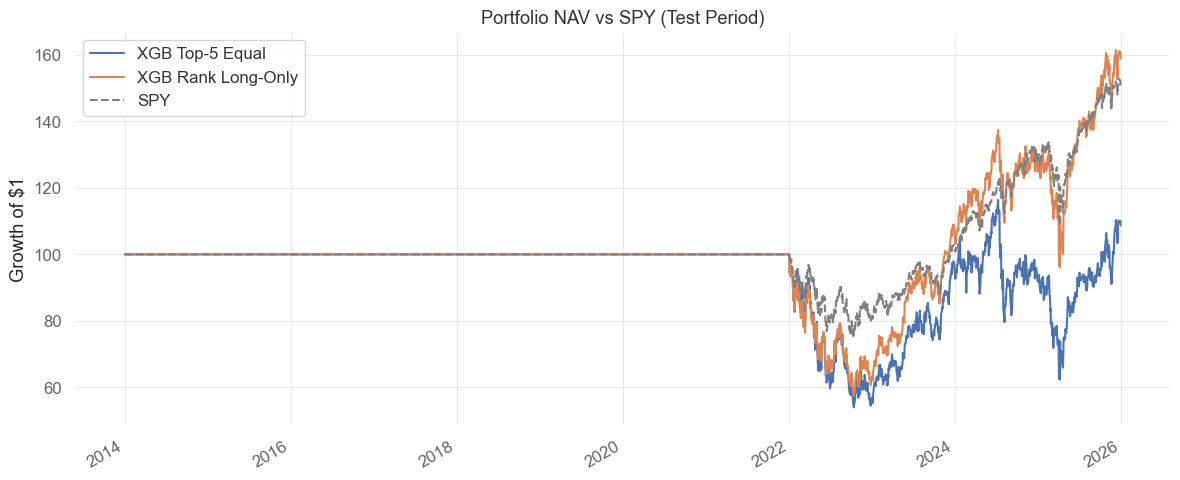

In [12]:
# NAV plot — shows cumulative growth relative to SPY
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

result_topk.nav.rename(f"XGB Top-{TOP_K} Equal").plot(ax=ax)
result_rank.nav.rename("XGB Rank Long-Only").plot(ax=ax)

# SPY NAV from either result (they share the same benchmark)
spy_nav = (1 + result_topk.benchmark_returns).cumprod() *100
spy_nav['SPY'].rename("SPY").plot(ax=ax, linestyle="--", color="gray")

ax.set_title("Portfolio NAV vs SPY (Test Period)")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Log to MLflow

Logs both strategies as separate runs, including params, predictions, weights, and QuantStats artifacts.

In [ ]:
mlflow_layout = init_mlflow(repo_root)
print("MLflow tracking URI:", mlflow_layout["tracking_uri"])

# --- Run 1: Top-K Equal ---
#with start_run(
#    run_name     = f"xgb_top{TOP_K}_equal",
#    dataset_name = DATASET_NAME,
#    tags = {"model": "xgboost", "horizon": str(HORIZON), "top_k": str(TOP_K)},
#    repo_root    = repo_root,
#):
#    mlflow.log_params({
#        "model"            : "xgboost",
#        "dataset_name"     : DATASET_NAME,
#        "horizon"          : HORIZON,
#        "top_k"            : TOP_K,
#        "feature_count"    : len(FEATURE_NAMES),
#        "feature_list"     : ",".join(FEATURE_NAMES),
#        "n_estimators"     : 300,
#        "max_depth"        : 4,
#        "learning_rate"    : 0.05,
#        "portfolio_builder": "top_k_equal",
#    })
#    log_predictions(predictions)
#    log_portfolio(portfolio_topk)
#    log_backtest(result_topk)

# --- Run 2: Rank Long-Only ---
with start_run(
    run_name     = "Eamon_Init",
    dataset_name = DATASET_NAME,
    tags = {"model": "xgboost", "horizon": str(HORIZON)},
    repo_root    = repo_root,
):
    mlflow.log_params({
        "model"            : "xgboost",
        "dataset_name"     : DATASET_NAME,
        "horizon"          : HORIZON,
        "feature_count"    : len(FEATURE_NAMES),
        "feature_list"     : ",".join(FEATURE_NAMES),
        "n_estimators"     : 300,
        "max_depth"        : 4,
        "learning_rate"    : 0.05,
        "portfolio_builder": "rank_long_only",
    })
    log_predictions(predictions)
    log_portfolio(portfolio_rank)
    log_backtest(result_rank)

print("MLflow logging complete.")

MLflow tracking URI: https://adams-macbook-pro.tail5ddc35.ts.net
🏃 View run xgb_top5_equal at: https://adams-macbook-pro.tail5ddc35.ts.net/#/experiments/1/runs/cf95906bc0bb406eb310609ef46c3afe
🧪 View experiment at: https://adams-macbook-pro.tail5ddc35.ts.net/#/experiments/1
🏃 View run xgb_rank_long_only at: https://adams-macbook-pro.tail5ddc35.ts.net/#/experiments/1/runs/1559cf78b8e04f46bb8a77f58828edf2
🧪 View experiment at: https://adams-macbook-pro.tail5ddc35.ts.net/#/experiments/1
MLflow logging complete.
